<h1> Experiment anti HOM probability against bandwith </h1>

In [6]:
#General imports
resol = 300
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, FuncFormatter
import pandas as pd

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "axes.linewidth": 0.7,
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,
})

import sys
import numpy as np
from pathlib import Path
pi = np.pi

project_root = Path().resolve().parents[0]
sys.path.append(str(project_root))

#Local imports
from experiments.coincidence_vs_bandwith import run_coincidence_vs_bandwith
from src.coincidence_theory import get_C

<h2> Execute the experiment </h2>

In [7]:
#Physical parameters
omega_A = 10*pi
Gamma = 5*pi

#Different photon frequencies
omega_q_tab = [9.5*pi, 9*pi, 8.5*pi]

delta_q = 0.05*pi

#Prepare a tab of IR and UV cutoffs for each experiment
nb_pts_bandwith = 15
ir_tab_list = []
uv_tab_list = []

#Experiments 1,2,3,4 : different central frequencies
central_freqs_1 = [10*pi, 9.5*pi, 9*pi, 8.5*pi]
for i in range(4):
    bandwith_tab = np.linspace(pi, 15*pi, nb_pts_bandwith)
    ir_tab_list.append(central_freqs_1[i] - bandwith_tab)
    uv_tab_list.append(central_freqs_1[i] + bandwith_tab)

#Experiments 5,6,7,8 : bad choices of central frequencies, below physical TLS frequency
central_freqs_2 = [0*pi, 0.5*pi, 1*pi, 1.5*pi]
for i in range(4):
    bandwith_tab = np.linspace(pi, 15*pi, nb_pts_bandwith) #negative frequencies included
    ir_tab_list.append(central_freqs_2[i] - bandwith_tab)
    uv_tab_list.append(central_freqs_2[i] + bandwith_tab)

Run the experiment

In [8]:
#Order of the bare parameters
n = 1 #to run
index_omega_q_to_run = [1,2,3]
xp_to_run = [2,3,4]

for index_omega_q in index_omega_q_to_run:
        for index_experiment in xp_to_run:
                print(f"Running index omega q {index_omega_q} for frequency window {index_experiment}")

                omega_q = omega_q_tab[index_omega_q-1]

                i = index_experiment - 1

                ir_tab = ir_tab_list[i]
                uv_tab = uv_tab_list[i]

                #Parameters of the simulation
                L = 50

                param_cavity_physical = {'omega_A': omega_A, 'Gamma': Gamma, 'L': L}

                param_time_evol = {'T': L/2, 'dt': 0.01}

                param_photons = {'omega_p': [omega_q, omega_q], 
                                'delta_k': [delta_q, delta_q],
                                'x_0': [-L/4, -L/4]}
                        
                _, _, coincidence_tab = run_coincidence_vs_bandwith(param_photons, param_cavity_physical, param_time_evol, ir_tab, uv_tab, 
                                                                index_omega_q, index_experiment, n=n)
                
                print("------------- \n")

Running index omega q 1 for frequency window 2


100%|██████████| 15/15 [24:44<00:00, 98.96s/it] 


------------- 

Running index omega q 1 for frequency window 3


100%|██████████| 15/15 [25:34<00:00, 102.27s/it]


------------- 

Running index omega q 1 for frequency window 4


...

------------- 

Running index omega q 3 for frequency window 3


100%|██████████| 15/15 [23:34<00:00, 94.31s/it] 


------------- 

Running index omega q 3 for frequency window 4


100%|██████████| 15/15 [26:13<00:00, 104.89s/it]

------------- 



<h2> Convergence per truncation scheme </h2>

Recover the data

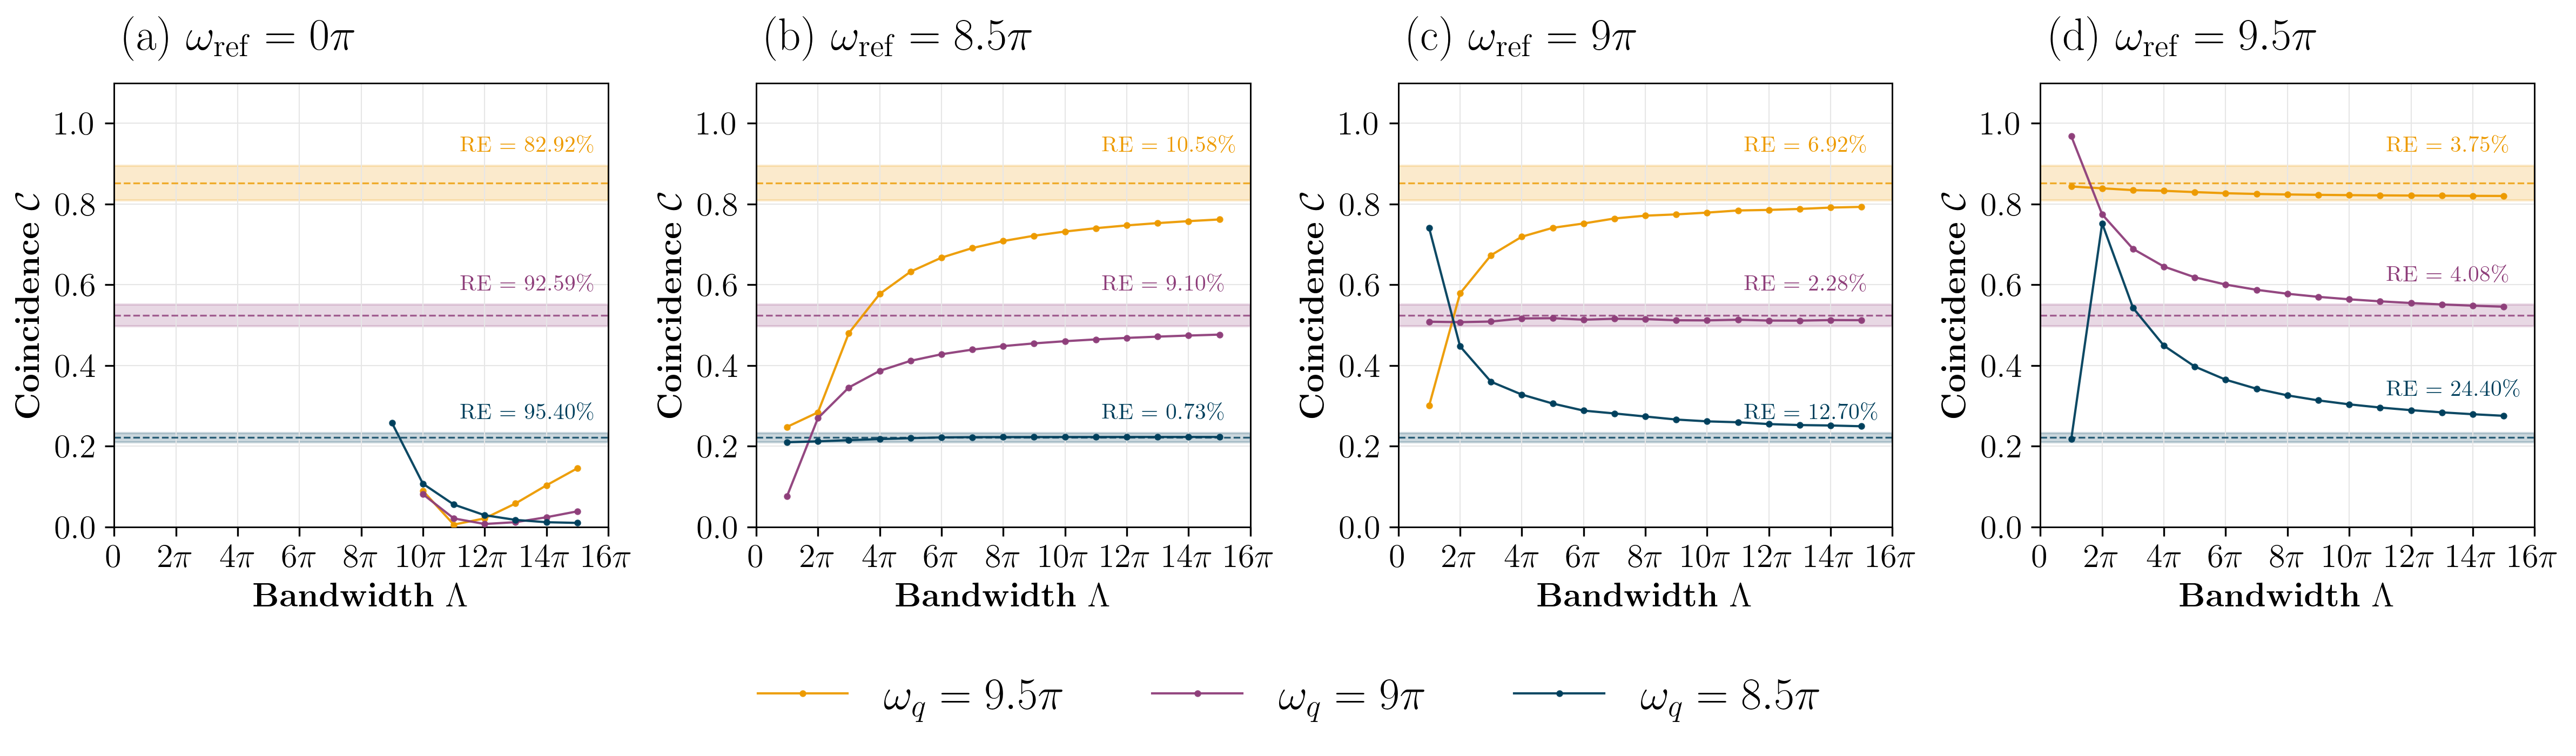

In [22]:

# =========================
# Paramètres communs
# =========================
index_experiments = [5, 4, 3, 2]  # tes expériences
max_x = 16*pi

n_value = -1
colors = ["#ed9a00","#8e3e7a","#003f5c"]
labels = [r'$\omega_q = 9.5\pi$', r'$\omega_q = 9\pi$', r'$\omega_q = 8.5\pi$']
subfig_labels = [r'(a) $\omega_{\rm ref} = 0\pi$', 
                 r'(b) $\omega_{\rm ref} = 8.5\pi$',
                 r'(c) $\omega_{\rm ref} = 9\pi$',
                 r'(d) $\omega_{\rm ref} = 9.5\pi$',]

# =========================
# Préparer la figure et axes (1 ligne)
# =========================
fig, axs = plt.subplots(1, 4, figsize=(16, 4), dpi=300, sharex=True)
axs = axs.flat
fig.subplots_adjust(wspace=0.3)  # espacement horizontal

# =========================
# Boucle sur les expériences
# =========================
for idx, ax in enumerate(axs):
    index_experiment = index_experiments[idx]


    coincidence_to_plot = []
    omega_available = []
    bandwith_to_plot = []
    theoretical_val_list = []
    relative_error_list = []

    # Charger les données
    for j in range(len(omega_q_tab)):
        try:
            index_omega_q = j+1
            data_file = f"../results/csv_files/coincidence_vs_bandwidth/{index_experiment}/coincidence_vs_bandwith_omega{index_omega_q}_xp{index_experiment}_n{n_value}.csv"

            df = pd.read_csv(data_file)
            coincidence_tab = df['coincidence_tab'].to_numpy()
            ir_tab = df['ir_tab'].to_numpy()
            uv_tab = df['uv_tab'].to_numpy()

            theoretical_val = get_C(omega_A, Gamma, omega_q_tab[index_omega_q-1])

            coincidence_to_plot.append(coincidence_tab)
            omega_available.append(j)
            bandwith_to_plot.append(0.5*(uv_tab - ir_tab))
            theoretical_val_list.append(theoretical_val)
            relative_error_list.append(np.abs(coincidence_to_plot[-1][-1] - theoretical_val_list[-1])/theoretical_val_list[-1])

        except Exception:
            print(f'xp{index_experiment}, omega_q index {index_omega_q} not available')
            continue

    # =========================
    # Plots sur l'axe courant
    # =========================
    for j in range(len(omega_available)):

        ax.plot(
            bandwith_to_plot[j],
            coincidence_to_plot[j],
            marker='o',
            markersize=2,
            label=labels[omega_available[j]],
            color=colors[j],
            linewidth=1,
            alpha=0.95,
            zorder=3
        )

        ax.hlines(
            theoretical_val_list[j],
            0,
            max_x,
            color=colors[j],
            linestyle='--',
            linewidth=0.8,
            alpha=0.8,
            zorder=2
        )

        ax.fill_between(
            x=np.linspace(0, max_x, 500),
            y1=0.95*theoretical_val_list[j],
            y2=1.05*theoretical_val_list[j],
            color=colors[j],
            alpha=0.2,
            zorder=1
        )

        if idx == 3 and (j==1 or j==2):  # seulement pour le dernier subplot
            y_text = 1.05*coincidence_to_plot[j][-1] + 0.05
        else:
            y_text = 1.05*theoretical_val_list[j] + 0.05

        ax.text(
            0.7,
            y_text,
            f'RE = {relative_error_list[j]*100:.2f}\\%',
            color=colors[j],
            fontsize=10,
            va='center',
            ha='left',
            transform=ax.get_yaxis_transform()
        )


    # =========================
    # Lettre + omega_ref en haut
    # =========================
    ax.text(0.02, 1.05, subfig_labels[idx], 
            transform=ax.transAxes, fontsize=20, fontweight='bold', va='bottom')

    # Grille
    ax.grid(color='0.9', linestyle='-', linewidth=0.5)

    # Axes labels
    ax.set_xlabel(r'\textbf{Bandwidth} $\Lambda$', fontsize=11)
    ax.set_ylabel(r'\textbf{Coincidence} $\mathcal{C}$', fontsize=11)

    # Tick styling
    ax.tick_params(axis='both', which='major', length=4, width=0.8, labelsize=9)
    ax.set_xlim([0, max_x])
    ax.set_ylim([0, 1.1])

    # Tick x en unités de π
    ax.xaxis.set_major_locator(MultipleLocator(2*np.pi))
    def pi_formatter(x, pos):
        n = x / np.pi
        if np.isclose(n, 0):
            return "0"
        elif np.isclose(n, 1):
            return r"$\pi$"
        else:
            return rf"${int(round(n))}\pi$"
    ax.xaxis.set_major_formatter(FuncFormatter(pi_formatter))

        #font size
    for item in [ax.xaxis.label, ax.yaxis.label]:
        item.set_fontsize(15)

    for item in (ax.get_xticklabels() + ax.get_yticklabels()):
        item.set_fontsize(15)

# =========================
# Légende commune en dessous
# =========================
handles, _ = axs[0].get_legend_handles_labels()  # ne prend que le premier subplot
fig.legend(
    handles,                   # les lignes principales
    labels,                    # tes labels explicites
    loc='upper center',
    bbox_to_anchor=(0.5, 0),
    ncol=3,
    frameon=False,
    fontsize=20
)

plt.tight_layout()
plt.savefig("../results/fig/coincidence_vs_bandwith_baseline.pdf", bbox_inches='tight', pad_inches=0.2)
plt.show()